In [3]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# fetching data
- using fetch_openml() to fetch credit-g dataset
- data.data returns the input rows

In [4]:

from sklearn.datasets import fetch_openml
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# fetch_openml is the most robust way to get the exact dataset in Colab without API keys
data = fetch_openml(name='credit-g', version=1, as_frame=True, parser='auto')
X = data.data
X.shape

(1000, 20)

In [5]:
X.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,4,real estate,67,none,own,2,skilled,1,yes,yes
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,2,real estate,22,none,own,1,skilled,1,none,yes
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,4,life insurance,45,none,for free,1,skilled,2,none,yes
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,4,no known property,53,none,for free,2,skilled,2,none,yes


# getting the target variables
- data.target gives the target variables
- mapping it 0 or 1

In [6]:
y = data.target.map({'good': 0, 'bad': 1})


In [7]:
dataset = pd.concat([X,y],axis=1)

# checking the dataset quality

In [8]:

print(f"Shape of X: {X.shape}")
print(X.info())



Shape of X: (1000, 20)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   category
 1   duration                1000 non-null   int64   
 2   credit_history          1000 non-null   category
 3   purpose                 1000 non-null   category
 4   credit_amount           1000 non-null   int64   
 5   savings_status          1000 non-null   category
 6   employment              1000 non-null   category
 7   installment_commitment  1000 non-null   int64   
 8   personal_status         1000 non-null   category
 9   other_parties           1000 non-null   category
 10  residence_since         1000 non-null   int64   
 11  property_magnitude      1000 non-null   category
 12  age                     1000 non-null   int64   
 13  other_payment_plans     1000 non-null   category
 14  housing      

In [9]:
missing = X.isnull().sum()
print(f"missing: {missing}")

missing: checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status            0
employment                0
installment_commitment    0
personal_status           0
other_parties             0
residence_since           0
property_magnitude        0
age                       0
other_payment_plans       0
housing                   0
existing_credits          0
job                       0
num_dependents            0
own_telephone             0
foreign_worker            0
dtype: int64


In [10]:
print(f"duplicated rows: {X.duplicated().sum()}")

duplicated rows: 0


In [11]:

target_col = "class"
if target_col in dataset.columns:
    print(dataset[target_col].value_counts(normalize=True)*100)


class
0    70.0
1    30.0
Name: proportion, dtype: float64


In [12]:
print(X.dtypes)

checking_status           category
duration                     int64
credit_history            category
purpose                   category
credit_amount                int64
savings_status            category
employment                category
installment_commitment       int64
personal_status           category
other_parties             category
residence_since              int64
property_magnitude        category
age                          int64
other_payment_plans       category
housing                   category
existing_credits             int64
job                       category
num_dependents               int64
own_telephone             category
foreign_worker            category
dtype: object


In [13]:
print(X.describe(include='all'))

       checking_status     duration  ... own_telephone foreign_worker
count             1000  1000.000000  ...          1000           1000
unique               4          NaN  ...             2              2
top        no checking          NaN  ...          none            yes
freq               394          NaN  ...           596            963
mean               NaN    20.903000  ...           NaN            NaN
std                NaN    12.058814  ...           NaN            NaN
min                NaN     4.000000  ...           NaN            NaN
25%                NaN    12.000000  ...           NaN            NaN
50%                NaN    18.000000  ...           NaN            NaN
75%                NaN    24.000000  ...           NaN            NaN
max                NaN    72.000000  ...           NaN            NaN

[11 rows x 20 columns]


In [14]:

dataset["class"] = dataset["class"].astype(int)
numeric_df = dataset.select_dtypes(include="number")
corr = numeric_df.corr()
print(corr["class"].abs().sort_values(ascending=False))

class                     1.000000
duration                  0.214927
credit_amount             0.154739
age                       0.091127
installment_commitment    0.072404
existing_credits          0.045732
num_dependents            0.003015
residence_since           0.002967
Name: class, dtype: float64


# seperating numerical columns and categorical columns

# train test split 
- creating three splits
- one for training, one for validation and one for final testing


### First Split: Extract the untouchable Test set (20%)
### We allocate 80% to an intermediate 'Train_Val' pool


### Second Split: Partition the intermediate pool into Train (60% total) and Validation (20% total)
### Since Train_Val is 80% of the total, taking 25% of it yields 20% of the total data (0.25 * 0.80 = 0.20)

In [15]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

X_train_unsampled, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,
    stratify=y_train_val,
    random_state=42
)

# Smote resampling on training data

In [16]:

numerical_cols = X.select_dtypes(include=['int64', 'float64', 'number']).columns.tolist()
categorical_cols = X.select_dtypes(include=['category', 'object']).columns.tolist()

print(f"Numerical features ({len(numerical_cols)}): {numerical_cols}")
print()
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")

Numerical features (7): ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']

Categorical features (13): ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']


In [17]:
from imblearn.over_sampling import SMOTENC
sm = SMOTENC(categorical_features=categorical_cols,sampling_strategy="minority" , random_state=42)


In [18]:
X_train_res, y_train_res = sm.fit_resample(X_train_unsampled, y_train)

y_train_res.value_counts(normalize=True) *100
X_train_res = pd.DataFrame(X_train_res, columns=X.columns)

# using ColumnTransformer to scale the numerical columns and onehot encode the categorical coding


```
preprocessor = ColumnTransformer(
    transformers=[
        ('name_1', transformer_object_1, columns_to_use_1),
        ('name_2', transformer_object_2, columns_to_use_2),
        # ... you can add as many tuples as needed
    ],
    remainder='drop', # Default: 'drop'. Alternatives: 'passthrough'
    verbose_feature_names_out=True
)
```
## preprocessor.fit(X) to fit the transformation on X
## preprocessor.set_output(transform="pandas") to transform the fitted X to pandas

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ],
    remainder="passthrough"
    )
preprocessor.set_output(transform="pandas")


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``.

In [20]:
X_train = preprocessor.fit_transform(X_train_res)
X_val = preprocessor.transform(X_val)
X_test = preprocessor.transform(X_test)
y_train = y_train_res

In [21]:
print(f"Dataset securely partitioned:")
print(f"  Training Set   (for base models):   X: {X_train.shape}, y: {y_train.shape}")
print(f"  Validation Set (for meta-learning): X: {X_val.shape}, y: {y_val.shape}")
print(f"  Test Set       (for final eval):    X: {X_test.shape}, y: {y_test.shape}")

# Verify stratification integrity
# Fix: Cast to int to allow mean calculation on categorical data
train_ratio = y_train.astype(int).mean()
val_ratio = y_val.astype(int).mean()
test_ratio = y_test.astype(int).mean()

print(f"\nStratification Check (Proportion of 'bad' risk):")
print(f"  Train: {train_ratio:.4f} | Val: {val_ratio:.4f} | Test: {test_ratio:.4f}")

Dataset securely partitioned:
  Training Set   (for base models):   X: (840, 48), y: (840,)
  Validation Set (for meta-learning): X: (200, 48), y: (200,)
  Test Set       (for final eval):    X: (200, 48), y: (200,)

Stratification Check (Proportion of 'bad' risk):
  Train: 0.5000 | Val: 0.3000 | Test: 0.3000


# creating ML models

In [22]:

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier


lr_model = LogisticRegression(max_iter=1000, random_state=42)


svm_model = SVC(kernel='rbf', probability=True, random_state=42)

# MLP architecture: 1 hidden layer with 64 neurons.
# ReLU activation introduces non-linearity, Adam optimizer handles weight updates.
mlp_model = MLPClassifier(hidden_layer_sizes=(64,), activation='relu',
                          solver='adam', max_iter=1000, random_state=42)

random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10 )

base_models = {
    'Logistic_Regression': lr_model,
    'SVM': svm_model,
    'MLP': mlp_model,
    "Random Forest": random_forest_model
}

print("Base models initialized.")

Base models initialized.


In [23]:
# [Cell 2.2] K-Fold OOF Predictions and Final Training
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss

K = 5
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

# Pre-allocate arrays for OOF probabilities (N_train x 3)
N_train = X_train.shape[0]
oof_P_train = np.zeros((N_train, len(base_models)))

print(f"Executing {K}-Fold Cross Validation on Train Set (N={N_train})...")

for i, (name, model) in enumerate(base_models.items()):
    oof_preds = np.zeros(N_train)

    # K-Fold loop for Out-of-Fold predictions
    for train_idx, val_idx in skf.split(X_train, y_train):
        # Extract fold specific matrices
        X_fold_train, y_fold_train = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]

        # Fit on (K-1) folds
        model.fit(X_fold_train, y_fold_train)

        # Predict probability of the positive class (class 1) on the 1 holdout fold
        oof_preds[val_idx] = model.predict_proba(X_fold_val)[:, 1]

    oof_P_train[:, i] = oof_preds

    # Calculate OOF metrics
    oof_auc = roc_auc_score(y_train, oof_preds)
    print(f"  {name:20s} - OOF ROC-AUC: {oof_auc:.4f}")

    # Retrain the model on the full training set for maximum representation
    model.fit(X_train, y_train)

print("\nFinal base models trained on the complete Train set.")

Executing 5-Fold Cross Validation on Train Set (N=840)...
  Logistic_Regression  - OOF ROC-AUC: 0.8879
  SVM                  - OOF ROC-AUC: 0.8951
  MLP                  - OOF ROC-AUC: 0.8649
  Random Forest        - OOF ROC-AUC: 0.8982

Final base models trained on the complete Train set.


In [ ]:
# [Cell 2.3] Generate Prediction Matrix P on Validation Set
# N_val is the number of rows in the validation set.
N_val = X_val.shape[0]
P_val = np.zeros((N_val, len(base_models)))

print(f"Generating Matrix P on Validation Set (N={N_val})...")

for i, (name, model) in enumerate(base_models.items()):
    # Extract the probability of the positive class (default risk)
    P_val[:, i] = model.predict_proba(X_val)[:, 1]

print(f"Matrix P_val shape: {P_val.shape}")
print("Sample of P_val (first 3 rows):")
print(np.round(P_val[:3, :], 4))

# Explicitly assign target vector y_val for optimization blocks
y_val_array = y_val.values


Generating Matrix P on Validation Set (N=200)...
Matrix P_val shape: (200, 4)
Sample of P_val (first 3 rows):
[[0.0285 0.0657 0.0195 0.1976]
 [0.2414 0.242  0.042  0.4047]
 [0.0243 0.0113 0.     0.0508]]


array([[2.85001809e-02, 6.56798923e-02, 1.95442819e-02, 1.97629785e-01],
       [2.41403590e-01, 2.41954938e-01, 4.19946456e-02, 4.04733146e-01],
       [2.42635338e-02, 1.13024931e-02, 3.31483236e-05, 5.07637870e-02],
       [2.21647815e-02, 1.41158612e-02, 1.53618379e-06, 3.51835714e-02],
       [9.27108657e-01, 9.27233027e-01, 9.99775560e-01, 7.85848464e-01],
       [7.81295081e-01, 5.60571612e-01, 1.34460982e-02, 4.87111525e-01],
       [6.78091121e-01, 4.34308094e-01, 4.91800974e-01, 4.45111388e-01],
       [5.21896713e-01, 5.33670361e-01, 1.19377685e-01, 5.39007412e-01],
       [4.76521474e-01, 4.81029592e-01, 9.97339590e-01, 3.20023267e-01],
       [2.81400527e-01, 1.53150645e-01, 3.56573336e-05, 3.07595162e-01],
       [5.70796979e-01, 5.96004189e-01, 2.26858462e-01, 5.55243427e-01],
       [3.52114216e-01, 4.54866285e-01, 8.44101341e-01, 4.66014543e-01],
       [7.46018517e-01, 8.68821249e-01, 9.84285004e-01, 6.53446765e-01],
       [6.85093447e-01, 8.64395286e-01, 9.64689942e

In [25]:
# [Cell 3.1] Construct QP Matrix Q and Vector c

print("Constructing Quadratic Programming matrices...")

# P_val is of shape (N_val, 3)
# y_val_array is of shape (N_val,)

# Q = 2 * P^T P
Q = 2 * np.dot(P_val.T, P_val)

# c = -2 * P^T y
# Reshape y_val_array to (N_val, 1) to ensure strict matrix algebra alignment
c = -2 * np.dot(P_val.T, y_val_array.reshape(-1, 1))

# Flatten c back to a 1D array for scipy.optimize compatibility
c = c.flatten()

print(f"Matrix Q shape: {Q.shape}")
print(Q)
print(f"\nVector c shape: {c.shape}")
print(c)

Constructing Quadratic Programming matrices...
Matrix Q shape: (4, 4)
[[ 95.07052347  89.20207206  94.43070163  80.36653417]
 [ 89.20207206  91.03825541  96.0468345   77.92002944]
 [ 94.43070163  96.0468345  127.652531    82.05832575]
 [ 80.36653417  77.92002944  82.05832575  75.42951657]]

Vector c shape: (4,)
[-61.95952395 -62.56105819 -70.04523923 -58.01323716]


In [26]:
# [Cell 3.2] Solve for optimal ensemble weights using SLSQP
from scipy.optimize import minimize

# 1. Define the strictly formulated QP objective function
def qp_objective(w, Q, c):
    # 0.5 * w^T * Q * w + c^T * w
    quadratic_term = 0.5 * np.dot(w.T, np.dot(Q, w))
    linear_term = np.dot(c.T, w)
    return quadratic_term + linear_term

# 2. Define the equality constraint: sum of weights must equal 1
# Scipy requires constraints in the form of f(w) = 0
constraints = ({
    'type': 'eq',
    'fun': lambda w: np.sum(w) - 1.0
})

# 3. Define the non-negativity bounds for each weight
# w_i in [0, 1] for all i
num_models = P_val.shape[1]
bounds = tuple((0.0, 1.0) for _ in range(num_models))

# 4. Initialize starting weights (e.g., uniform distribution)
w_init = np.ones(num_models) / num_models

# 5. Execute SLSQP optimization
print("Executing SLSQP solver...")
result = minimize(
    fun=qp_objective,
    x0=w_init,
    args=(Q, c),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'disp': True, 'ftol': 1e-9} # High precision tolerance
)

# 6. Extract and verify results
if result.success:
    w_QP = result.x
    print("\n--- Mathematical Benchmark Reached ---")
    print("Optimal Weights (w_QP):")
    for name, weight in zip(base_models.keys(), w_QP):
        print(f"  {name:20s}: {weight:.6f}")

    print(f"\nSum of weights: {np.sum(w_QP):.6f}")

    # Calculate continuous MSE for the optimal ensemble
    optimal_preds = np.dot(P_val, w_QP)
    # Fix: Ensure y_val_array is numeric to allow subtraction
    y_val_numeric = y_val_array.astype(float)
    mse_optimal = np.mean((optimal_preds - y_val_numeric) ** 2)
    print(f"Benchmark Ensemble Validation MSE: {mse_optimal:.6f}")
else:
    print("Optimization failed:", result.message)

Executing SLSQP solver...
Optimization terminated successfully    (Exit mode 0)
            Current function value: -20.68790966250417
            Iterations: 6
            Function evaluations: 31
            Gradient evaluations: 6

--- Mathematical Benchmark Reached ---
Optimal Weights (w_QP):
  Logistic_Regression : 0.000000
  SVM                 : 0.063985
  MLP                 : 0.119786
  Random Forest       : 0.816229

Sum of weights: 1.000000
Benchmark Ensemble Validation MSE: 0.196560


In [27]:
# [Cell 4.1] Define the Continuous Objective Function

def normalize_weights(w):
    """Enforces non-negativity and sum-to-one constraints."""
    w_abs = np.abs(w)
    # Add a small epsilon to prevent division by zero
    w_norm = w_abs / (np.sum(w_abs) + 1e-10)
    return w_norm

def objective_function(w, P, y):
    """
    Computes the Mean Squared Error for a given weight vector.
    P: Prediction matrix (N x 3)
    y: True labels (N,)
    """
    w_norm = normalize_weights(w)
    ensemble_preds = np.dot(P, w_norm)
    mse = np.mean((ensemble_preds - y) ** 2)
    return mse

print("Objective function and constraint normalizer defined.")

Objective function and constraint normalizer defined.


Initializing ACOR: 40 ants, 100 iterations...
  Iteration  20/100 - Best MSE: 0.196560
  Iteration  40/100 - Best MSE: 0.196560
  Iteration  60/100 - Best MSE: 0.196560
  Iteration  80/100 - Best MSE: 0.196560
  Iteration 100/100 - Best MSE: 0.196560


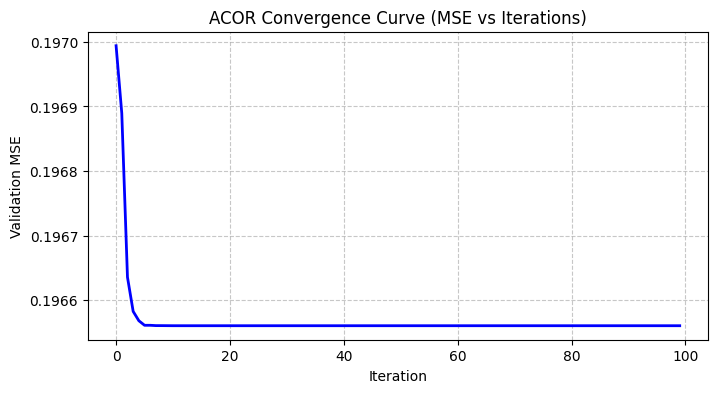

In [28]:
# [Cell 4.2] Implement Continuous Ant Colony Optimization (ACOR)
import matplotlib.pyplot as plt

def run_acor(P, y, num_models, n_ants=40, archive_size=20, iterations=100, q=0.1, xi=0.85):
    """
    q: Locality of the search process. Small q favors the best-ranked solutions strongly.
    xi: Convergence speed (analogous to pheromone evaporation).
    """
    print(f"Initializing ACOR: {n_ants} ants, {iterations} iterations...")

    # 1. Initialize the Solution Archive with random weights
    archive = np.random.rand(archive_size, num_models)
    archive = np.array([normalize_weights(w) for w in archive])

    # Evaluate initial archive
    scores = np.array([objective_function(w, P, y) for w in archive])

    # Sort archive by score (ascending, since we minimize MSE)
    sort_idx = np.argsort(scores)
    archive = archive[sort_idx]
    scores = scores[sort_idx]

    # Calculate selection probabilities based on rank (Gaussian function)
    ranks = np.arange(1, archive_size + 1)
    weights = (1 / (q * archive_size * np.sqrt(2 * np.pi))) * \
              np.exp(-((ranks - 1)**2) / (2 * (q * archive_size)**2))
    selection_probs = weights / np.sum(weights)

    convergence_curve = np.zeros(iterations)

    # 2. Main ACOR Loop
    for iter in range(iterations):
        new_solutions = np.zeros((n_ants, num_models))
        new_scores = np.zeros(n_ants)

        for ant in range(n_ants):
            # Choose a guiding solution from the archive based on selection_probs
            guide_idx = np.random.choice(archive_size, p=selection_probs)
            guide_solution = archive[guide_idx]

            # Calculate dynamic standard deviation (sigma) for the Gaussian kernel
            # Sigma is proportional to the average distance to other solutions in the archive
            sigma = xi * np.sum(np.abs(archive - guide_solution), axis=0) / (archive_size - 1)

            # Sample new continuous weights
            sampled_w = np.random.normal(loc=guide_solution, scale=sigma)
            sampled_w = normalize_weights(sampled_w)

            new_solutions[ant] = sampled_w
            new_scores[ant] = objective_function(sampled_w, P, y)

        # 3. Update Archive
        # Combine old archive and new solutions
        combined_archive = np.vstack((archive, new_solutions))
        combined_scores = np.concatenate((scores, new_scores))

        # Sort and keep the best `archive_size` solutions
        sort_idx = np.argsort(combined_scores)
        archive = combined_archive[sort_idx][:archive_size]
        scores = combined_scores[sort_idx][:archive_size]

        # Track best MSE
        convergence_curve[iter] = scores[0]

        if (iter + 1) % 20 == 0:
            print(f"  Iteration {iter+1:3d}/{iterations} - Best MSE: {scores[0]:.6f}")

    return archive[0], scores[0], convergence_curve

# Execute the algorithm
num_base_models = P_val.shape[1]
# Fix: Explicitly cast y_val_array to float to avoid categorical subtraction error
y_val_numeric = y_val_array.astype(float)
w_ACO_raw, mse_ACO, convergence = run_acor(P_val, y_val_numeric, num_models=num_base_models)
w_ACO = normalize_weights(w_ACO_raw)

# Plot convergence for strict performance verification
plt.figure(figsize=(8, 4))
plt.plot(convergence, color='blue', linewidth=2)
plt.title('ACOR Convergence Curve (MSE vs Iterations)')
plt.xlabel('Iteration')
plt.ylabel('Validation MSE')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [29]:
# [Cell 4.3] Compare w_ACO with w_QP
print("--- Weight Optimization Comparison ---")
print(f"{'Model':<25} | {'QP Weights':<15} | {'ACO Weights':<15}")
print("-" * 60)

for idx, name in enumerate(base_models.keys()):
    print(f"{name:<25} | {w_QP[idx]:<15.6f} | {w_ACO[idx]:<15.6f}")

print("-" * 60)
print(f"{'Validation MSE':<25} | {mse_optimal:<15.6f} | {mse_ACO:<15.6f}")

# Calculate the Euclidean distance between the two weight vectors
l2_distance = np.linalg.norm(w_QP - w_ACO)
print(f"\nL2 Norm (Euclidean Distance) between w_QP and w_ACO: {l2_distance:.6f}")

if l2_distance < 0.05:
    print("Conclusion: ACOR successfully converged near the global mathematical optimum.")
else:
    print("Conclusion: ACOR found a sub-optimal local minimum. Consider tuning 'q' and 'xi' parameters.")

--- Weight Optimization Comparison ---
Model                     | QP Weights      | ACO Weights    
------------------------------------------------------------
Logistic_Regression       | 0.000000        | 0.000000       
SVM                       | 0.063985        | 0.063985       
MLP                       | 0.119786        | 0.119786       
Random Forest             | 0.816229        | 0.816229       
------------------------------------------------------------
Validation MSE            | 0.196560        | 0.196560       

L2 Norm (Euclidean Distance) between w_QP and w_ACO: 0.000000
Conclusion: ACOR successfully converged near the global mathematical optimum.


In [30]:
# [Cell 5.1] Define Custom 1D ANFIS Architecture in PyTorch

import torch.nn as nn
import torch.nn.functional as F

class GaussianMF(nn.Module):
    def __init__(self, centers, sigmas):
        super(GaussianMF, self).__init__()
        # centers and sigmas are initialized as learnable parameters
        self.centers = nn.Parameter(torch.tensor(centers, dtype=torch.float32))
        self.sigmas = nn.Parameter(torch.tensor(sigmas, dtype=torch.float32))

    def forward(self, x):
        # x shape: (batch_size, 1)
        # Output shape: (batch_size, num_rules)
        return torch.exp(-0.5 * ((x - self.centers) / self.sigmas) ** 2)

class ANFIS1D(nn.Module):
    def __init__(self):
        super(ANFIS1D, self).__init__()
        # Initialize 3 rules: Low, Medium, High risk
        # We intuitively distribute the initial centers across the [0, 1] probability space
        initial_centers = [0.1, 0.5, 0.9]
        initial_sigmas = [0.2, 0.2, 0.2]

        self.fuzzify = GaussianMF(initial_centers, initial_sigmas)

        # Consequent parameters for First-Order Takagi-Sugeno
        # For 3 rules, we need 3 'a' parameters and 3 'b' parameters
        self.a = nn.Parameter(torch.tensor([0.0, 0.5, 1.0], dtype=torch.float32))
        self.b = nn.Parameter(torch.tensor([0.0, 0.0, 0.0], dtype=torch.float32))

    def forward(self, x):
        # 1. Fuzzification
        w = self.fuzzify(x) # Shape: (batch_size, 3)

        # 2. Normalization
        w_sum = torch.sum(w, dim=1, keepdim=True)
        # Add epsilon to prevent division by zero
        w_norm = w / (w_sum + 1e-8)

        # 3. Consequent Evaluation (f_i = a_i * x + b_i)
        # x is (batch_size, 1), a and b are (3,)
        f = x * self.a + self.b # Shape: (batch_size, 3)

        # 4. Final Output Calculation
        output = torch.sum(w_norm * f, dim=1) # Shape: (batch_size,)
        return output

print("Takagi-Sugeno ANFIS model architecture defined.")

Takagi-Sugeno ANFIS model architecture defined.


In [31]:
# [Cell 5.2] Train ANFIS Model on Validation Set
import torch.optim as optim

# 1. Prepare the data
# Generate the optimized continuous predictions using w_ACO
ensemble_preds_val = np.dot(P_val, w_ACO)

# Convert to PyTorch tensors
X_tensor = torch.tensor(ensemble_preds_val, dtype=torch.float32).view(-1, 1)
y_tensor = torch.tensor(y_val_array, dtype=torch.float32)

# 2. Initialize Model, Loss, and Optimizer
anfis_model = ANFIS1D()
criterion = nn.MSELoss()
# Adam optimizer handles both premise (centers/sigmas) and consequent (a/b) parameters
optimizer = optim.Adam(anfis_model.parameters(), lr=0.01)

# 3. Training Loop
epochs = 500
print("Initiating ANFIS Hybrid Learning...")

for epoch in range(epochs):
    optimizer.zero_grad()

    # Forward pass
    outputs = anfis_model(X_tensor)

    # Compute loss
    loss = criterion(outputs, y_tensor)

    # Backward pass and optimize
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"  Epoch {epoch+1:3d}/{epochs} - Loss (MSE): {loss.item():.6f}")

print("\n--- ANFIS Training Complete ---")

# 4. Extract and print the learned fuzzy rules for interpretability
learned_centers = anfis_model.fuzzify.centers.detach().numpy()
learned_sigmas = anfis_model.fuzzify.sigmas.detach().numpy()

print("\nLearned Linguistic Variables (Gaussian MFs):")
print(f"  Rule 1 (Low Risk):    Center = {learned_centers[0]:.4f}, Sigma = {learned_sigmas[0]:.4f}")
print(f"  Rule 2 (Medium Risk): Center = {learned_centers[1]:.4f}, Sigma = {learned_sigmas[1]:.4f}")
print(f"  Rule 3 (High Risk):   Center = {learned_centers[2]:.4f}, Sigma = {learned_sigmas[2]:.4f}")

# Function to map a probability to a linguistic interpretation based on max membership
def interpret_risk(p_val):
    p_tensor = torch.tensor([[p_val]], dtype=torch.float32)
    memberships = anfis_model.fuzzify(p_tensor).detach().numpy()[0]
    rule_idx = np.argmax(memberships)
    labels = ["Low Risk", "Medium Risk", "High Risk"]
    return labels[rule_idx], memberships

print("\nExample Interpretations:")
sample_probs = [0.15, 0.45, 0.85]
for p in sample_probs:
    label, mems = interpret_risk(p)
    print(f"  Ensemble Prob {p:.2f} -> {label} (Memberships: L:{mems[0]:.2f}, M:{mems[1]:.2f}, H:{mems[2]:.2f})")

Initiating ANFIS Hybrid Learning...
  Epoch 100/500 - Loss (MSE): 0.181846
  Epoch 200/500 - Loss (MSE): 0.180609
  Epoch 300/500 - Loss (MSE): 0.182237
  Epoch 400/500 - Loss (MSE): 0.182615
  Epoch 500/500 - Loss (MSE): 0.182137

--- ANFIS Training Complete ---

Learned Linguistic Variables (Gaussian MFs):
  Rule 1 (Low Risk):    Center = 0.1203, Sigma = 0.0134
  Rule 2 (Medium Risk): Center = 0.7786, Sigma = 0.1131
  Rule 3 (High Risk):   Center = 1.3423, Sigma = -0.0619

Example Interpretations:
  Ensemble Prob 0.15 -> Low Risk (Memberships: L:0.09, M:0.00, H:0.00)
  Ensemble Prob 0.45 -> Medium Risk (Memberships: L:0.00, M:0.01, H:0.00)
  Ensemble Prob 0.85 -> Medium Risk (Memberships: L:0.00, M:0.82, H:0.00)


In [32]:
# [Cell 6] Final Evaluation Pipeline
print("Initiating Final Test Phase on untouched data...")

# ---------------------------------------------------------
# Cell 6.1: Run the Test set through the Base Models
# ---------------------------------------------------------
N_test = X_test.shape[0]
P_test = np.zeros((N_test, len(base_models)))

for i, (name, model) in enumerate(base_models.items()):
    # Extract probability of the positive class (class 1: default risk)
    P_test[:, i] = model.predict_proba(X_test)[:, 1]

print(f"Base model predictions generated. Matrix P_test shape: {P_test.shape}")

Initiating Final Test Phase on untouched data...
Base model predictions generated. Matrix P_test shape: (200, 4)


In [33]:
# ---------------------------------------------------------
# Cell 6.2: Apply w_ACO for final ML prediction score
# ---------------------------------------------------------
# final_test_probs is the continuous array p in [0, 1]
final_test_probs = np.dot(P_test, w_ACO)
print("ACO-optimized weights applied to test predictions.")

ACO-optimized weights applied to test predictions.


In [34]:
# ---------------------------------------------------------
# Cell 6.3: ANFIS Interpretability Mapping
# ---------------------------------------------------------
# Convert probabilities to PyTorch tensor for the ANFIS fuzzification layer
test_probs_tensor = torch.tensor(final_test_probs, dtype=torch.float32).view(-1, 1)

# Pass through the trained Gaussian membership functions
memberships = anfis_model.fuzzify(test_probs_tensor).detach().numpy()

# Determine the linguistic risk class by taking the argmax of the membership degrees
rule_indices = np.argmax(memberships, axis=1)
risk_categories = np.array(["Low Risk", "Medium Risk", "High Risk"])
final_risk_labels = risk_categories[rule_indices]

print("ANFIS linguistic mapping complete.")

ANFIS linguistic mapping complete.


In [35]:
# ---------------------------------------------------------
# Cell 6.4: Output Strict Classification Metrics
# ---------------------------------------------------------
# Standard machine learning classification requires a hard threshold (p >= 0.5)
binary_predictions = (final_test_probs >= 0.5).astype(int)
y_test_array = y_test.values

# Calculate scalar metrics
precision = precision_score(y_test_array, binary_predictions)
recall = recall_score(y_test_array, binary_predictions)
f1 = f1_score(y_test_array, binary_predictions)
roc_auc = roc_auc_score(y_test_array, final_test_probs)
conf_matrix = confusion_matrix(y_test_array, binary_predictions)

print("\n" + "="*50)
print("FINAL ENSEMBLE TEST METRICS (ACO + ANFIS)")
print("="*50)
print(f"ROC-AUC Score: {roc_auc:.4f}  <- (Primary metric for probability separation)")
print(f"Precision:     {precision:.4f}  <- (When predicting Bad Risk, how often is it correct?)")
print(f"Recall:        {recall:.4f}  <- (Out of all actual Bad Risks, how many were found?)")
print(f"F1-Score:      {f1:.4f}  <- (Harmonic mean of Precision and Recall)")
print("-" * 50)
print("Confusion Matrix:")
print(f"True Negatives (Good predicted Good):  {conf_matrix[0, 0]}")
print(f"False Positives (Good predicted Bad):  {conf_matrix[0, 1]}")
print(f"False Negatives (Bad predicted Good):  {conf_matrix[1, 0]}")
print(f"True Positives (Bad predicted Bad):    {conf_matrix[1, 1]}")
print("="*50)

# ---------------------------------------------------------
# Display a sample of the integrated architecture output
# ---------------------------------------------------------
print("\nSample Pipeline Output (First 10 instances):")
results_df = pd.DataFrame({
    'True Label': y_test_array[:10],
    'ACO ML Prob': np.round(final_test_probs[:10], 4),
    'Binary Pred': binary_predictions[:10],
    'ANFIS Risk Class': final_risk_labels[:10]
})
print(results_df.to_string(index=False))


FINAL ENSEMBLE TEST METRICS (ACO + ANFIS)
ROC-AUC Score: 0.7368  <- (Primary metric for probability separation)
Precision:     0.4848  <- (When predicting Bad Risk, how often is it correct?)
Recall:        0.5333  <- (Out of all actual Bad Risks, how many were found?)
F1-Score:      0.5079  <- (Harmonic mean of Precision and Recall)
--------------------------------------------------
Confusion Matrix:
True Negatives (Good predicted Good):  106
False Positives (Good predicted Bad):  34
False Negatives (Bad predicted Good):  28
True Positives (Bad predicted Bad):    32

Sample Pipeline Output (First 10 instances):
True Label  ACO ML Prob  Binary Pred ANFIS Risk Class
         0       0.5172            1      Medium Risk
         0       0.2508            0      Medium Risk
         1       0.7338            1      Medium Risk
         0       0.6495            1      Medium Risk
         1       0.4334            0      Medium Risk
         0       0.3762            0      Medium Risk
  